In [4]:
from google.colab import drive
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

# Mount Google Drive
drive.mount('/content/drive')

folder_name = 'COMP6001_Dataset'

# definign paths
base_path = f'/content/drive/MyDrive/{folder_name}'
sharp_path = os.path.join(base_path, 'val2017')
blurred_path = os.path.join(base_path, 'val2017_blurred_deterministic')
json_path = os.path.join(base_path, 'blur_metadata.json')

# 4. metadata 'transformations' section
if os.path.exists(json_path):
    with open(json_path, 'r') as f:
        full_metadata = json.load(f)
    # The image details are kept inside 'transformations'
    metadata = full_metadata.get('transformations', {})
    print(f"Success! Loaded metadata for {len(metadata)} images.")
else:
    print(f"File not found at: {json_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Success! Loaded metadata for 5000 images.


In [5]:
def create_kernel(length, angle):
    # Determine the size of the filter based on the metadata 'size'
    size = max(int(round(length)), 1)
    if size % 2 == 0: size += 1

    # Create a horizontal line representing the camera movement
    kernel = np.zeros((size, size))
    center = size // 2
    kernel[center, :] = 1.0

    # Rotate that line to the exact angle from the JSON
    # We use -angle because OpenCV rotations are counter-clockwise
    matrix = cv2.getRotationMatrix2D((center, center), -angle, 1.0)
    kernel = cv2.warpAffine(kernel, matrix, (size, size))

    # Normalize the filter so the image doesn't get too bright or dark
    return kernel / np.sum(kernel)

def wiener_deblur(img, kernel, K=0.01):
    # Transform the image and filter into the 'Frequency Domain'
    img_fft = np.fft.fft2(img)
    kernel_fft = np.fft.fft2(kernel, s=img.shape)

    # Apply the Wiener formula to reverse the blur while ignoring noise
    kernel_fft_conj = np.conj(kernel_fft)
    denom = np.abs(kernel_fft)**2 + K
    wiener_filter = kernel_fft_conj / denom

    # Bring the image back from frequencies to actual pixels
    result = np.fft.ifft2(wiener_filter * img_fft)
    return np.abs(result)

Processing image: 000000140076.jpg
Blur parameters found -> Size: 7, Angle: 346.97


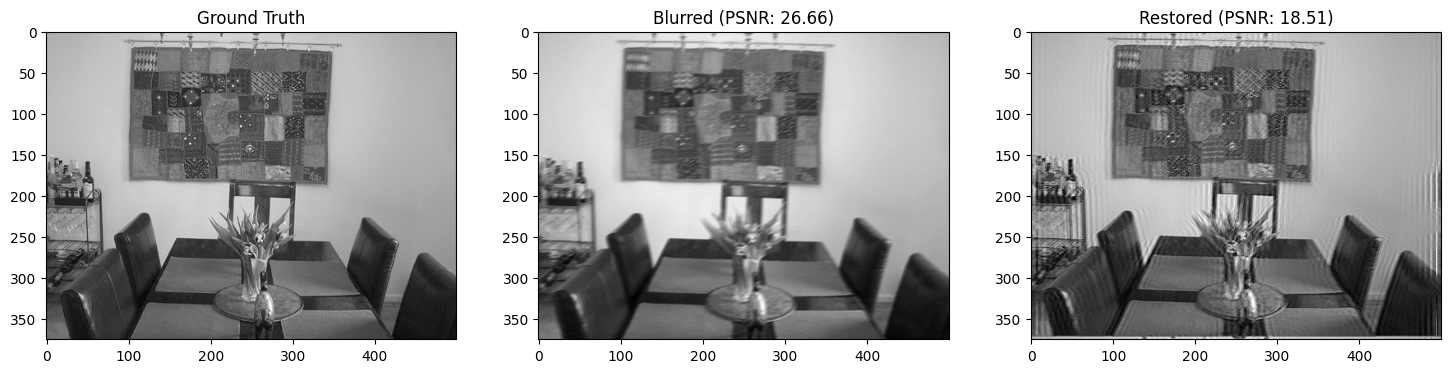

Final Improvement: -8.15 dB


In [6]:
# 1. Get a list of actual images (ignoring hidden files)
all_images = [f for f in os.listdir(sharp_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
sample_filename = all_images[0]

print(f"Processing image: {sample_filename}")

# 2. Look up the size and angle for this specific filename
sample_meta = metadata.get(sample_filename)

if sample_meta:
    b_len = sample_meta.get('size', 15)
    b_angle = sample_meta.get('angle', 0)
    print(f"Blur parameters found -> Size: {b_len}, Angle: {b_angle}")

    # 3. Load the images in Grayscale
    img_sharp = cv2.imread(os.path.join(sharp_path, sample_filename), 0)
    img_blurred = cv2.imread(os.path.join(blurred_path, sample_filename), 0)

    # 4. Generate the PSF (Point Spread Function) and deblur
    psf_kernel = create_kernel(b_len, b_angle)
    restored_raw = wiener_deblur(img_blurred, psf_kernel, K=0.01)

    # 5. Clean up the image for display
    restored_8bit = np.clip(restored_raw, 0, 255).astype(np.uint8)

    # 6. Calculate PSNR Improvement
    psnr_before = psnr_metric(img_sharp, img_blurred)
    psnr_after = psnr_metric(img_sharp, restored_8bit)

    # 7. Show the comparison
    plt.figure(figsize=(18, 6))
    plt.subplot(1,3,1); plt.imshow(img_sharp, cmap='gray'); plt.title("Ground Truth")
    plt.subplot(1,3,2); plt.imshow(img_blurred, cmap='gray'); plt.title(f"Blurred (PSNR: {psnr_before:.2f})")
    plt.subplot(1,3,3); plt.imshow(restored_8bit, cmap='gray'); plt.title(f"Restored (PSNR: {psnr_after:.2f})")
    plt.show()

    print(f"Final Improvement: {psnr_after - psnr_before:+.2f} dB")
else:
    print(f"Error: Could not find {sample_filename} in the transformations list.")